# **Маскалева Полина ЗФИбд-01-24 лабораторная работа № 3, вариант 13**

**ЛР 3 – Вариант 13**
1. Целевой столбец (отклик): Gender
2. Условие отбора записей: Married=Yes
3. Классический подход: линейный дискриминантный анализ (LDA)
4. Гиперпараметры нейронных сетей:
Кол-во скрытых слоев: 5
Кол-во нейронов в слое: 32
Оптимизатор: RMSprop
Функции активации в скрытых слоях: elu, selu, swish

1) Импортируем что нужно

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import RMSprop

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

2) Загружаем и готовим данные

In [32]:
# Загружаем данные
data = pd.read_csv('Credit_Data.csv')
print("Первые 5 строк исходных данных:")
data.head()

# Оставляем только строки с Married=Yes
data = data[data['Married'] == 'Yes'].copy()
print(f"Размер данных после фильтрации: {data.shape}")

# Создаем целевую переменную (Gender -> 0/1)
# Male -> 0, Female -> 1
data['Gender_target'] = data['Gender'].map({'Male': 0, 'Female': 1})
print("Распределение классов после кодировки:")
print(data['Gender_target'].value_counts())

# Исключаем ненужные столбцы: Gender, Student, Married, Ethnicity, ID
columns_to_drop = ['Gender', 'Student', 'Married', 'Ethnicity', 'ID']
X = data.drop(columns=columns_to_drop + ['Gender_target'], axis=1)
y = data['Gender_target']

print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер целевой переменной y: {y.shape}")
print("Признаки, используемые для обучения:")
print(X.columns.tolist())

# Разбиваем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Первые 5 строк исходных данных:
Размер данных после фильтрации: (245, 12)
Распределение классов после кодировки:
Gender_target
1    128
0    117
Name: count, dtype: int64
Размер матрицы признаков X: (245, 7)
Размер целевой переменной y: (245,)
Признаки, используемые для обучения:
['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education', 'Balance']
Обучающая выборка: (171, 7)
Тестовая выборка: (74, 7)


3) Классический подход LDA

In [33]:
# Создаем списки для хранения результатов
models = []
accuracies = []

# Обучаем модели для степени полинома от 2 до 5
for degree in range(2, 6):
    # Создаем конвейер как в примере из PDF
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('std_scaler', StandardScaler()),
        ('lda', LinearDiscriminantAnalysis())
    ])

    # Обучаем
    pipe.fit(X_train, y_train)

    # Предсказываем
    y_pred = pipe.predict(X_test)

    # Оцениваем качество
    acc = accuracy_score(y_test, y_pred)

    models.append(pipe)
    accuracies.append(acc)

    print(f"Степень полинома = {degree}, Accuracy = {acc:.4f}")

# Находим модель с наименьшей ошибкой (наибольшей accuracy)
best_idx = np.argmax(accuracies)
best_degree = range(2, 6)[best_idx]
best_model_classic = models[best_idx]
best_acc_classic = accuracies[best_idx]

print(f"Лучшая классическая модель: степень полинома {best_degree}")
print(f"Accuracy на тестовой выборке: {best_acc_classic:.4f}")


Степень полинома = 2, Accuracy = 0.4459
Степень полинома = 3, Accuracy = 0.4730
Степень полинома = 4, Accuracy = 0.3919
Степень полинома = 5, Accuracy = 0.4730
Лучшая классическая модель: степень полинома 3
Accuracy на тестовой выборке: 0.4730


4) Работаем с нейросетью

In [34]:
# ПРИНУДИТЕЛЬНОЕ ВКЛЮЧЕНИЕ EAGER EXECUTION
import tensorflow as tf
tf.config.run_functions_eagerly(True)
tf.data.experimental.enable_debug_mode()
print(f"TensorFlow version: {tf.__version__}")
print(f"Eager execution: {tf.executing_eagerly()}")

TensorFlow version: 2.19.0
Eager execution: True


In [35]:
print("Обуяение нейронных сетей")

# Преобразуем данные в numpy
X_train_np = np.array(X_train, dtype=np.float32)
X_test_np = np.array(X_test, dtype=np.float32)
y_train_np = np.array(y_train, dtype=np.float32)
y_test_np = np.array(y_test, dtype=np.float32)

print(f"Размер X_train: {X_train_np.shape}")
print(f"Размер y_train: {y_train_np.shape}")

# ПАРАМЕТРЫ
epochs = 30
batch_size = 32

# СЛОВАРИ ДЛЯ РЕЗУЛЬТАТОВ
histories = {}
models = {}
accuracies = {}

# 1. СЕТЬ 1 (ELU)
print("Обучение сети ELU")

model1 = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(input_shape=(X_train_np.shape[1],)),
    tf.keras.layers.Dense(32, activation='elu'),
    tf.keras.layers.Dense(32, activation='elu'),
    tf.keras.layers.Dense(32, activation='elu'),
    tf.keras.layers.Dense(32, activation='elu'),
    tf.keras.layers.Dense(32, activation='elu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optimizer1 = RMSprop(learning_rate=0.001)  # Создаем optimizer для этой модели
model1.compile(optimizer=optimizer1, loss='binary_crossentropy', metrics=['accuracy'])

history1 = model1.fit(
    X_train_np, y_train_np,
    validation_data=(X_test_np, y_test_np),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

loss1, acc1 = model1.evaluate(X_test_np, y_test_np, verbose=0)
print(f"Accuracy на тестовой выборке: {acc1:.4f}")

histories['elu'] = history1
models['elu'] = model1
accuracies['elu'] = acc1

# 2. СЕТЬ 2 (SELU)
print("Обучение сети SELU")

model2 = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(input_shape=(X_train_np.shape[1],)),
    tf.keras.layers.Dense(32, activation='selu'),
    tf.keras.layers.Dense(32, activation='selu'),
    tf.keras.layers.Dense(32, activation='selu'),
    tf.keras.layers.Dense(32, activation='selu'),
    tf.keras.layers.Dense(32, activation='selu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optimizer2 = RMSprop(learning_rate=0.001)  # Новый optimizer для второй модели
model2.compile(optimizer=optimizer2, loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    X_train_np, y_train_np,
    validation_data=(X_test_np, y_test_np),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

loss2, acc2 = model2.evaluate(X_test_np, y_test_np, verbose=0)
print(f"Accuracy на тестовой выборке: {acc2:.4f}")

histories['selu'] = history2
models['selu'] = model2
accuracies['selu'] = acc2

# 3. СЕТЬ 3 (SWISH)
print("Обучение сети SWISH")

model3 = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(input_shape=(X_train_np.shape[1],)),
    tf.keras.layers.Dense(32, activation='swish'),
    tf.keras.layers.Dense(32, activation='swish'),
    tf.keras.layers.Dense(32, activation='swish'),
    tf.keras.layers.Dense(32, activation='swish'),
    tf.keras.layers.Dense(32, activation='swish'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

optimizer3 = RMSprop(learning_rate=0.001)  # Новый optimizer для третьей модели
model3.compile(optimizer=optimizer3, loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(
    X_train_np, y_train_np,
    validation_data=(X_test_np, y_test_np),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

loss3, acc3 = model3.evaluate(X_test_np, y_test_np, verbose=0)
print(f"Accuracy на тестовой выборке: {acc3:.4f}")

histories['swish'] = history3
models['swish'] = model3
accuracies['swish'] = acc3

print("Обучение закончено")
print(f"Итоговые точности:")
for act, acc in accuracies.items():
    print(f"  {act}: {acc:.4f}")

Обуяение нейронных сетей
Размер X_train: (171, 7)
Размер y_train: (171,)
Обучение сети ELU
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.5539 - loss: 0.7076 - val_accuracy: 0.4865 - val_loss: 0.8737
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.5549 - loss: 0.6782 - val_accuracy: 0.4595 - val_loss: 0.7235
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.5955 - loss: 0.6803 - val_accuracy: 0.4865 - val_loss: 0.7419
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5562 - loss: 0.6666 - val_accuracy: 0.5541 - val_loss: 0.7307
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.5688 - loss: 0.6828 - val_accuracy: 0.4865 - val_loss: 0.7466
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.5929 - loss: 0.6567 - val_accuracy: 0.4730 - val_loss: 0.7260
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.5298 - loss: 0.6828 - val_accuracy: 0.4730 - val_loss: 0.7524
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━

5) Кривые обучения нейронных сетей

Кривые обучения


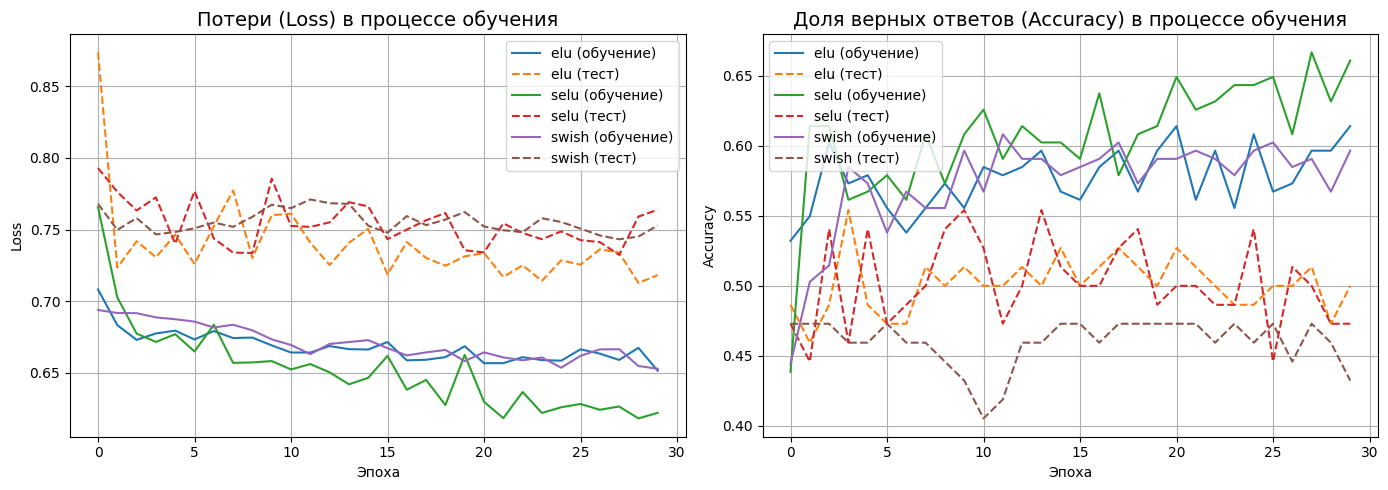

сокращение потерь
ELU: потери сократились с 0.7083 до 0.6515 (8.0%)
SELU: потери сократились с 0.7657 до 0.6222 (18.7%)
SWISH: потери сократились с 0.6939 до 0.6529 (5.9%)
Оценка качества обцчения
Сеть с активацией ELU:
Точность на обучении: 0.6140
Точность на тесте: 0.5000
Потери на обучении: 0.6515
Потери на тесте: 0.7183
  Статус: недообучилась
Сеть с активацией SELU:
Точность на обучении: 0.6608
Точность на тесте: 0.4730
Потери на обучении: 0.6222
Потери на тесте: 0.7639
  Статус: недообучилась
Сеть с активацией SWISH:
Точность на обучении: 0.5965
Точность на тесте: 0.4324
Потери на обучении: 0.6529
Потери на тесте: 0.7529
  Статус: недообучилась
Лучшая нейросеть
Лучшая модель: активация ELU
Accuracy на тестовой выборке: 0.5000


In [36]:
# 5.1 Кривые обучения
print("Кривые обучения")

#Потери (Loss)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for activation in ['elu', 'selu', 'swish']:
    history = histories[activation]
    plt.plot(history.history['loss'], label=f'{activation} (обучение)')
    plt.plot(history.history['val_loss'], '--', label=f'{activation} (тест)')
plt.title('Потери (Loss) в процессе обучения', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

#Доля верных ответов (Accuracy)
plt.subplot(1, 2, 2)
for activation in ['elu', 'selu', 'swish']:
    history = histories[activation]
    plt.plot(history.history['accuracy'], label=f'{activation} (обучение)')
    plt.plot(history.history['val_accuracy'], '--', label=f'{activation} (тест)')
plt.title('Доля верных ответов (Accuracy) в процессе обучения', fontsize=14)
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 5.2 Сокращение потерь
print("сокращение потерь")

for activation in ['elu', 'selu', 'swish']:
    history = histories[activation]
    loss_first = history.history['loss'][0]
    loss_last = history.history['loss'][-1]
    reduction = ((loss_first - loss_last) / loss_first) * 100
    print(f"{activation.upper()}: потери сократились с {loss_first:.4f} до {loss_last:.4f} ({reduction:.1f}%)")

# 5.3 Качество обучения
print("Оценка качества обцчения")
for activation in ['elu', 'selu', 'swish']:
    history = histories[activation]
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    print(f"Сеть с активацией {activation.upper()}:")
    print(f"Точность на обучении: {train_acc:.4f}")
    print(f"Точность на тесте: {val_acc:.4f}")
    print(f"Потери на обучении: {train_loss:.4f}")
    print(f"Потери на тесте: {val_loss:.4f}")

    # Определяем статус
    if val_acc < 0.6:
        status = "недообучилась"
    elif train_acc - val_acc > 0.2:
        status = "переобучилась"
    elif train_acc > 0.8 and val_acc > 0.75:
        status = "обучилась успешно"
    else:
        status = "обучилась удовлетворительно"

    print(f"  Статус: {status}")

# 5.4 Лучшая нейронка
print("Лучшая нейросеть")

best_activation = max(accuracies, key=accuracies.get)
best_model_nn = models[best_activation]
best_acc_nn = accuracies[best_activation]

print(f"Лучшая модель: активация {best_activation.upper()}")
print(f"Accuracy на тестовой выборке: {best_acc_nn:.4f}")



6) Кривые для лучших моделей

ROC-кривые лучших классификаторов
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Классическая модель (LDA, степень 3):
Accuracy = 0.4730
AUC = 0.4147
Модель нейронной секти (elu):
Accuracy = 0.5000
AUC = 0.5158
Модель с более высокой accuracy: Нейросетевая модель (красная линия на графике)


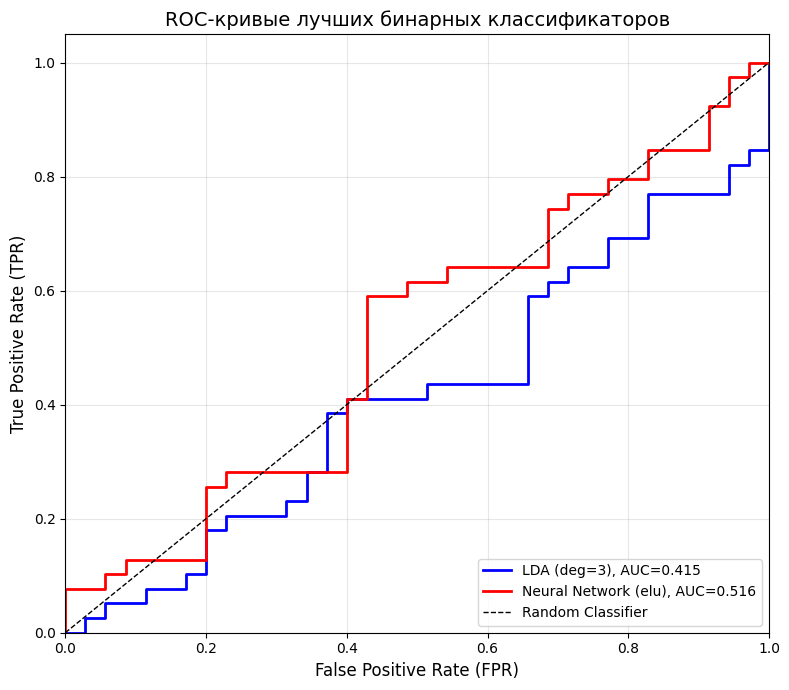

Вывод:
AUC классической модели (LDA): 0.4147
AUC нейросетевой модели (elu): 0.5158
Нейросетевая модель показывает лучшее качество по ROC-AUC


In [37]:

print("ROC-кривые лучших классификаторов")

# Получаем вероятности для лучшей классической модели (LDA)
y_proba_classic = best_model_classic.predict_proba(X_test)[:, 1]

# Получаем вероятности для лучшей нейросетевой модели
y_proba_nn = best_model_nn.predict(X_test_np).flatten()

# Вычисляем ROC-кривые
fpr_classic, tpr_classic, _ = roc_curve(y_test, y_proba_classic)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)

# Вычисляем площади под кривыми (AUC)
auc_classic = auc(fpr_classic, tpr_classic)
auc_nn = auc(fpr_nn, tpr_nn)

print(f"Классическая модель (LDA, степень {best_degree}):")
print(f"Accuracy = {best_acc_classic:.4f}")
print(f"AUC = {auc_classic:.4f}")

print(f"Модель нейронной секти ({best_activation}):")
print(f"Accuracy = {best_acc_nn:.4f}")
print(f"AUC = {auc_nn:.4f}")

# Определяем, у какой модели выше accuracy (для цвета)
if best_acc_classic > best_acc_nn:
    better_model = "Классическая модель (LDA)"
    classic_color = 'red'
    nn_color = 'blue'
else:
    better_model = "Нейросетевая модель"
    classic_color = 'blue'
    nn_color = 'red'

print(f"Модель с более высокой accuracy: {better_model} (красная линия на графике)")

# Визуализация ROC-кривых на одном рисунке
plt.figure(figsize=(8, 7))

# Рисуем ROC-кривые (красным - лучшую по accuracy)
plt.plot(fpr_classic, tpr_classic, color=classic_color, lw=2,
         label=f'LDA (deg={best_degree}), AUC={auc_classic:.3f}')
plt.plot(fpr_nn, tpr_nn, color=nn_color, lw=2,
         label=f'Neural Network ({best_activation}), AUC={auc_nn:.3f}')

# Диагональная линия (случайный классификатор)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые лучших бинарных классификаторов', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Вывод:")
print(f"AUC классической модели (LDA): {auc_classic:.4f}")
print(f"AUC нейросетевой модели ({best_activation}): {auc_nn:.4f}")
if auc_classic > auc_nn:
    print(f"Классическая модель показывает лучшее качество по ROC-AUC")
else:
    print(f"Нейросетевая модель показывает лучшее качество по ROC-AUC")
